# 01 — Spam (SMS Spam Collection)

Classe positiva: **é spam?** (`target = 1`). O texto bruto entra direto no pipeline (TfidfVectorizer é o primeiro passo).

In [1]:
# Configuração do ambiente (Google Colab). Fora do Colab, usa a pasta local do projeto.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/a2'   # fácil de trocar
    IN_COLAB = True
except ImportError:
    import os
    PROJECT_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
    IN_COLAB = False
%cd {PROJECT_DIR}
if IN_COLAB:
    !pip install -q -r requirements.txt
import sys; sys.path.insert(0, PROJECT_DIR)

C:\Users\otavi\OneDrive\Desktop\data science\a2


In [2]:
DOMAIN = "spam"
FORCE_RETRAIN = False   # True = ignora os checkpoints em outputs/spam/models/ e retreina

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import config, cutoff_hist, evaluate, explain, pipeline
from src.pipeline import timed

cfg = config.DOMAINS[DOMAIN]
OUT = config.output_dir(DOMAIN)
FX = OUT / "faixas"
T = config.THRESHOLD
FIGS = []

def show(path):
    """Registra a figura para o resumo e exibe no notebook."""
    FIGS.append(path.relative_to(OUT).as_posix())
    display(Image(filename=str(path)))

def table(df, stem):
    """Salva CSV + Markdown em outputs/<dominio>/ e exibe."""
    evaluate.save_table(df, OUT / stem)
    display(evaluate.round_table(df))

print(f"Domínio: {DOMAIN} | classe positiva: {cfg['positive_question']} | "
      f"métrica-alvo: {cfg['target_metric']} | limiar das métricas: {T}")

Domínio: spam | classe positiva: é spam? | métrica-alvo: average_precision | limiar das métricas: 0.5


## 1. Carregar os dados

In [3]:
with timed("carregar dados"):
    X, y = pipeline.load_domain_data(DOMAIN)
print(f"X: {X.shape} | positivos (target = 1): {y.sum()} ({100 * y.mean():.2f}%)")

[tempo] carregar dados: 0.0 s
X: (5171,) | positivos (target = 1): 653 (12.63%)


In [4]:
print(X.head())
assert X.dtype == object, "no spam, X deve ser o texto bruto"

0    Go until jurong point, crazy.. Available only ...
1                        Ok lar... Joking wif u oni...
2    Free entry in 2 a wkly comp to win FA Cup fina...
3    U dun say so early hor... U c already then say...
4    Nah I don't think he goes to usf, he lives aro...
Name: text, dtype: object


## 2. Balanceamento das classes

,classe,n,pct_do_total
0,1 = spam (é spam?),653,12.63
1,0 = ham (legítima),4518,87.37
2,Total,5171,100.00


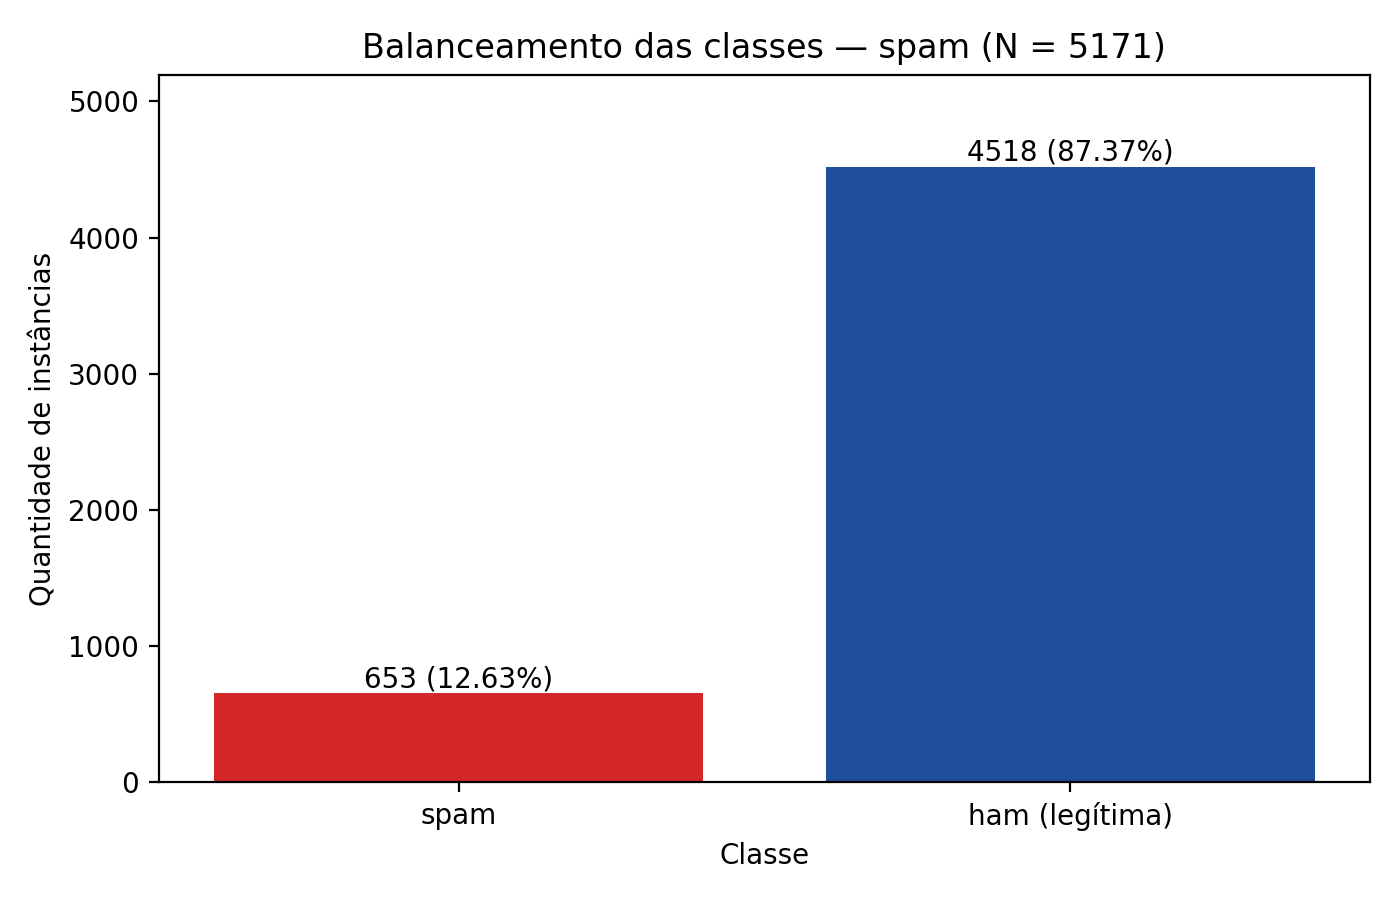

In [5]:
balanceamento = evaluate.class_balance_table(y, cfg)
table(balanceamento, "balanceamento")
show(evaluate.plot_class_balance(y, cfg, OUT / "01_balanceamento_classes.png",
                                 f"Balanceamento das classes — {DOMAIN} (N = {len(y)})"))

## 3. Split estratificado 60/20/20 (treino / validação / teste)

In [6]:
with timed("split"):
    splits = pipeline.split_data(X, y)
X_tr, y_tr = splits["treino"]
X_val, y_val = splits["validacao"]
X_te, y_te = splits["teste"]
table(pipeline.split_table(splits), "split")

[tempo] split: 0.0 s


,conjunto,n,pct_do_total,n_positivos,pct_positivos,n_negativos
0,treino,3102,59.99,392,12.64,2710
1,validacao,1034,20.00,130,12.57,904
2,teste,1035,20.02,131,12.66,904


## 4. Tuning por validação cruzada (somente no treino)

Pipeline completo (pré-processamento + modelo) dentro da busca; `StratifiedKFold(n_splits=5, shuffle=True)`. Checkpoint em `models/`.

In [7]:
tuned = pipeline.tune_all(DOMAIN, X_tr, y_tr, force_retrain=FORCE_RETRAIN)
hiperparametros = pipeline.hyperparams_table(tuned, cfg["target_metric"])
table(hiperparametros, "hiperparametros")

[checkpoint] Regressão Logística: carregado de regressao_logistica.joblib
[tempo] tuning Regressão Logística: 0.0 s
[checkpoint] Naive Bayes Multinomial: carregado de naive_bayes_multinomial.joblib
[tempo] tuning Naive Bayes Multinomial: 0.0 s


[checkpoint] LinearSVC calibrado: carregado de linearsvc_calibrado.joblib
[tempo] tuning LinearSVC calibrado: 0.0 s


,modelo,metrica_cv,cv_average_precision_media,cv_average_precision_desvio,cv_folds,candidatos_testados,tempo_tuning_s,melhores_hiperparametros
0,Regressão Logística,average_precision,0.9736,0.0119,5,48,33.6023,"C=10; tfidf__min_df=1; tfidf__ngram_range=(1, ..."
1,Naive Bayes Multinomial,average_precision,0.9715,0.0130,5,60,6.9058,alpha=0.1; tfidf__min_df=2; tfidf__ngram_range...
2,LinearSVC calibrado,average_precision,0.9744,0.0119,5,48,5.0927,estimator__C=1; tfidf__min_df=1; tfidf__ngram_...


## 5. Comparação dos modelos na validação (limiar = 0,5 nas métricas de decisão)

[tempo] avaliação na validação: 0.1 s


,modelo,limiar,acuracia,precisao,recall,f1,roc_auc,pr_auc_trapezoidal,average_precision_AP,TN,FP,FN,TP
0,Regressão Logística,0.5,0.9816,0.9664,0.8846,0.9237,0.9956,0.9789,0.9790,900,4,15,115
1,Naive Bayes Multinomial,0.5,0.9845,1.0000,0.8769,0.9344,0.9887,0.9678,0.9678,904,0,16,114
2,LinearSVC calibrado,0.5,0.9826,0.9118,0.9538,0.9323,0.9956,0.9769,0.9770,892,12,6,124


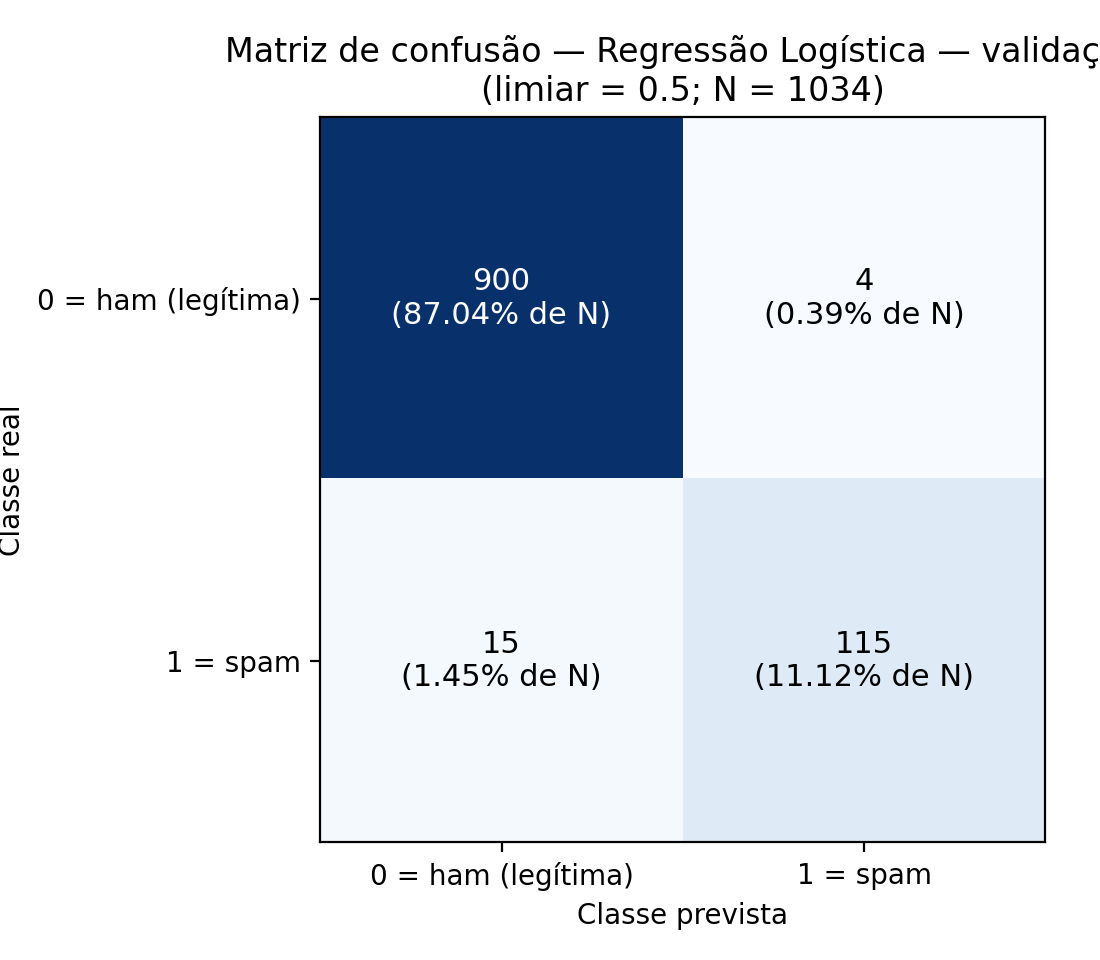

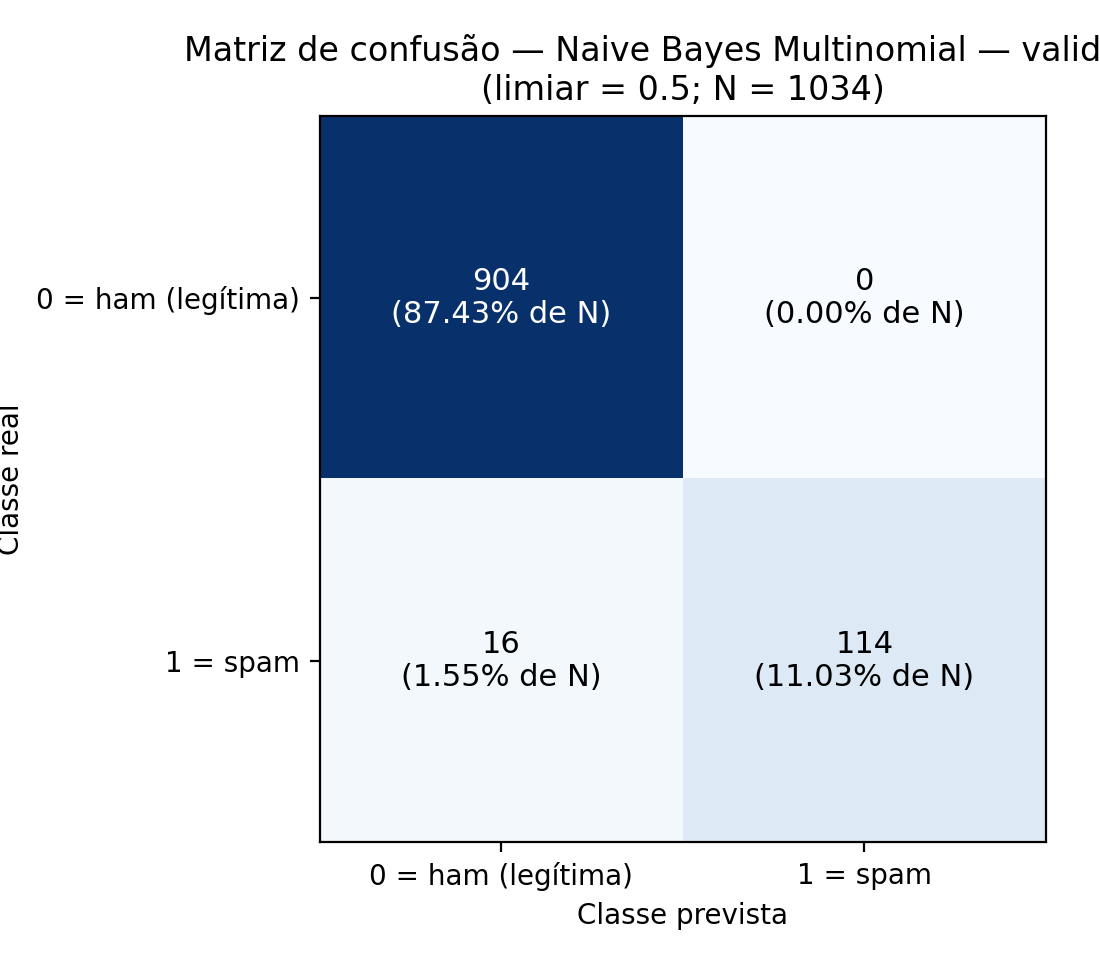

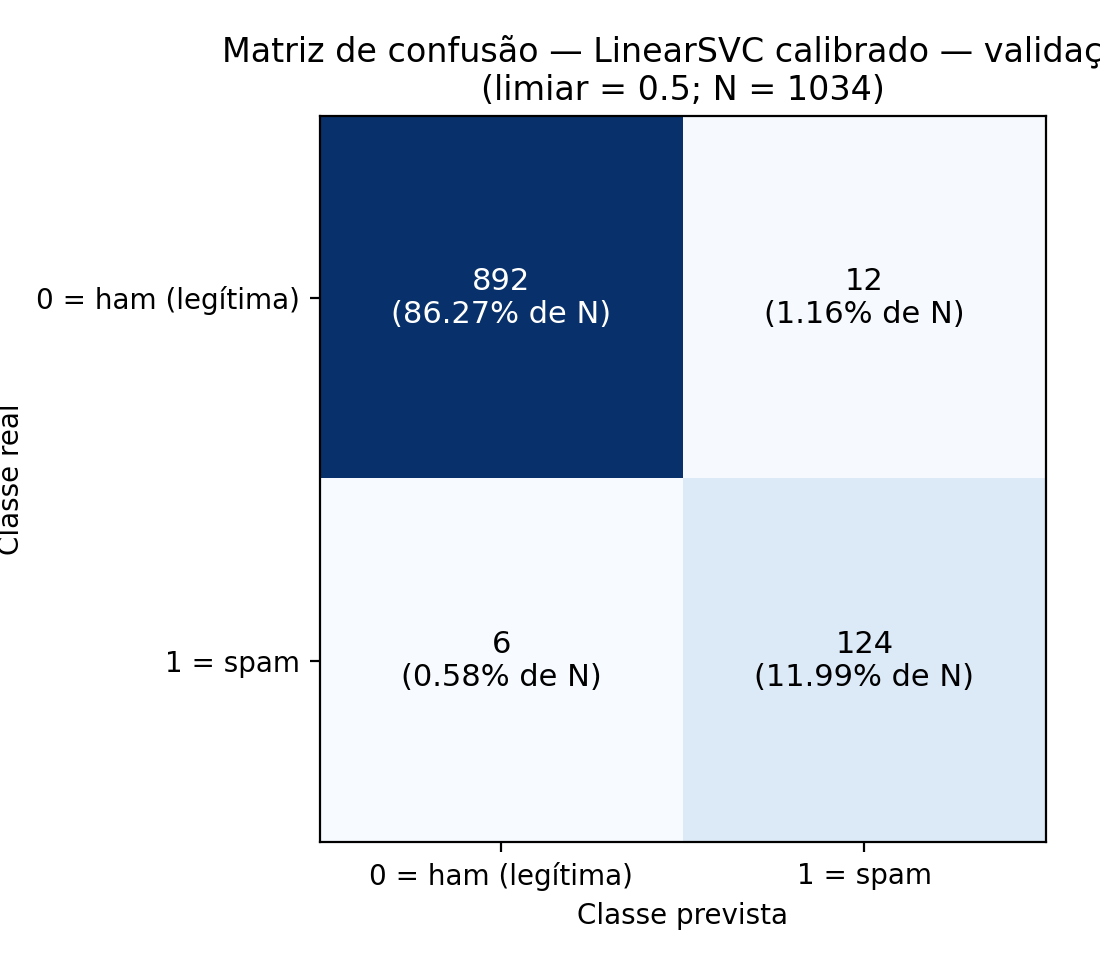

In [8]:
with timed("avaliação na validação"):
    val_probas = {name: pipeline.predict_positive(ck["estimator"], X_val)
                  for name, ck in tuned.items()}
    comparacao = evaluate.comparison_table(y_val, val_probas)
table(comparacao, "comparacao_validacao")
for name, p in val_probas.items():
    show(evaluate.plot_confusion(
        y_val, p, cfg, OUT / f"02_matriz_confusao_validacao_{pipeline.slug(name)}.png",
        f"Matriz de confusão — {name} — validação"))

## 6. Seleção do melhor modelo (métrica-alvo na validação)

In [9]:
best_name, best_col, best_value = evaluate.select_best(comparacao, cfg["target_metric"])
best = tuned[best_name]["estimator"]
selecao = f"{best_name} — maior {best_col} na validação = {best_value:.4f}"
print("Melhor modelo:", selecao)

Melhor modelo: Regressão Logística — maior average_precision_AP na validação = 0.9790


## 7. Curvas ROC e PR na validação

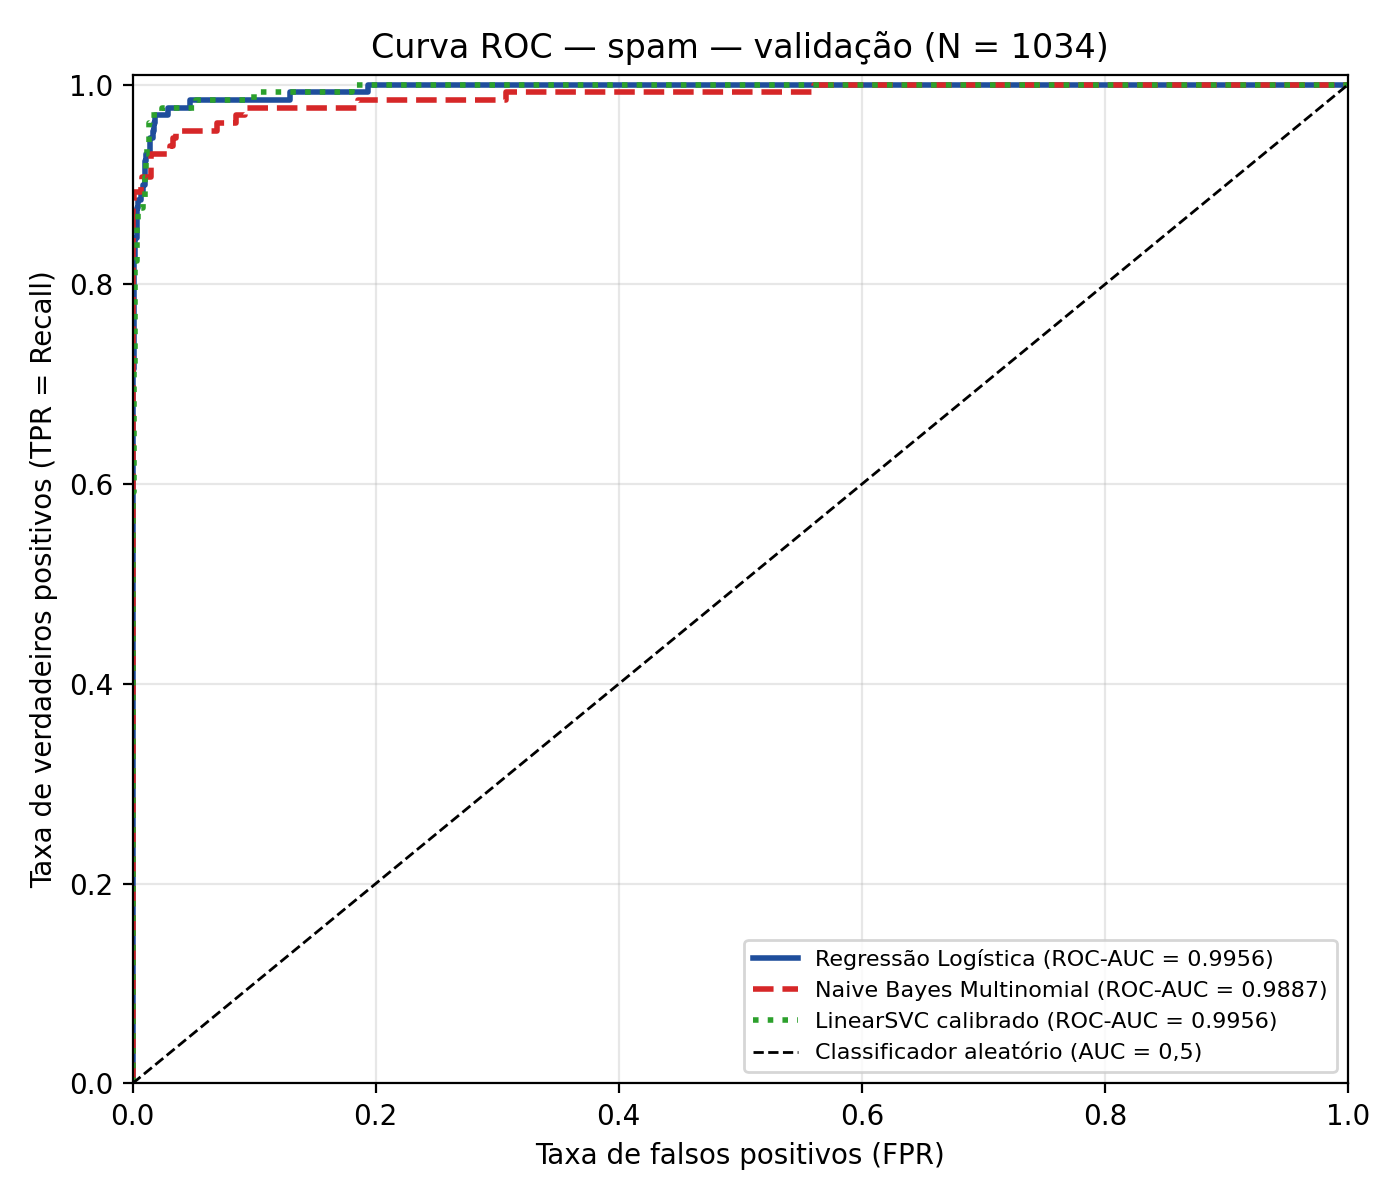

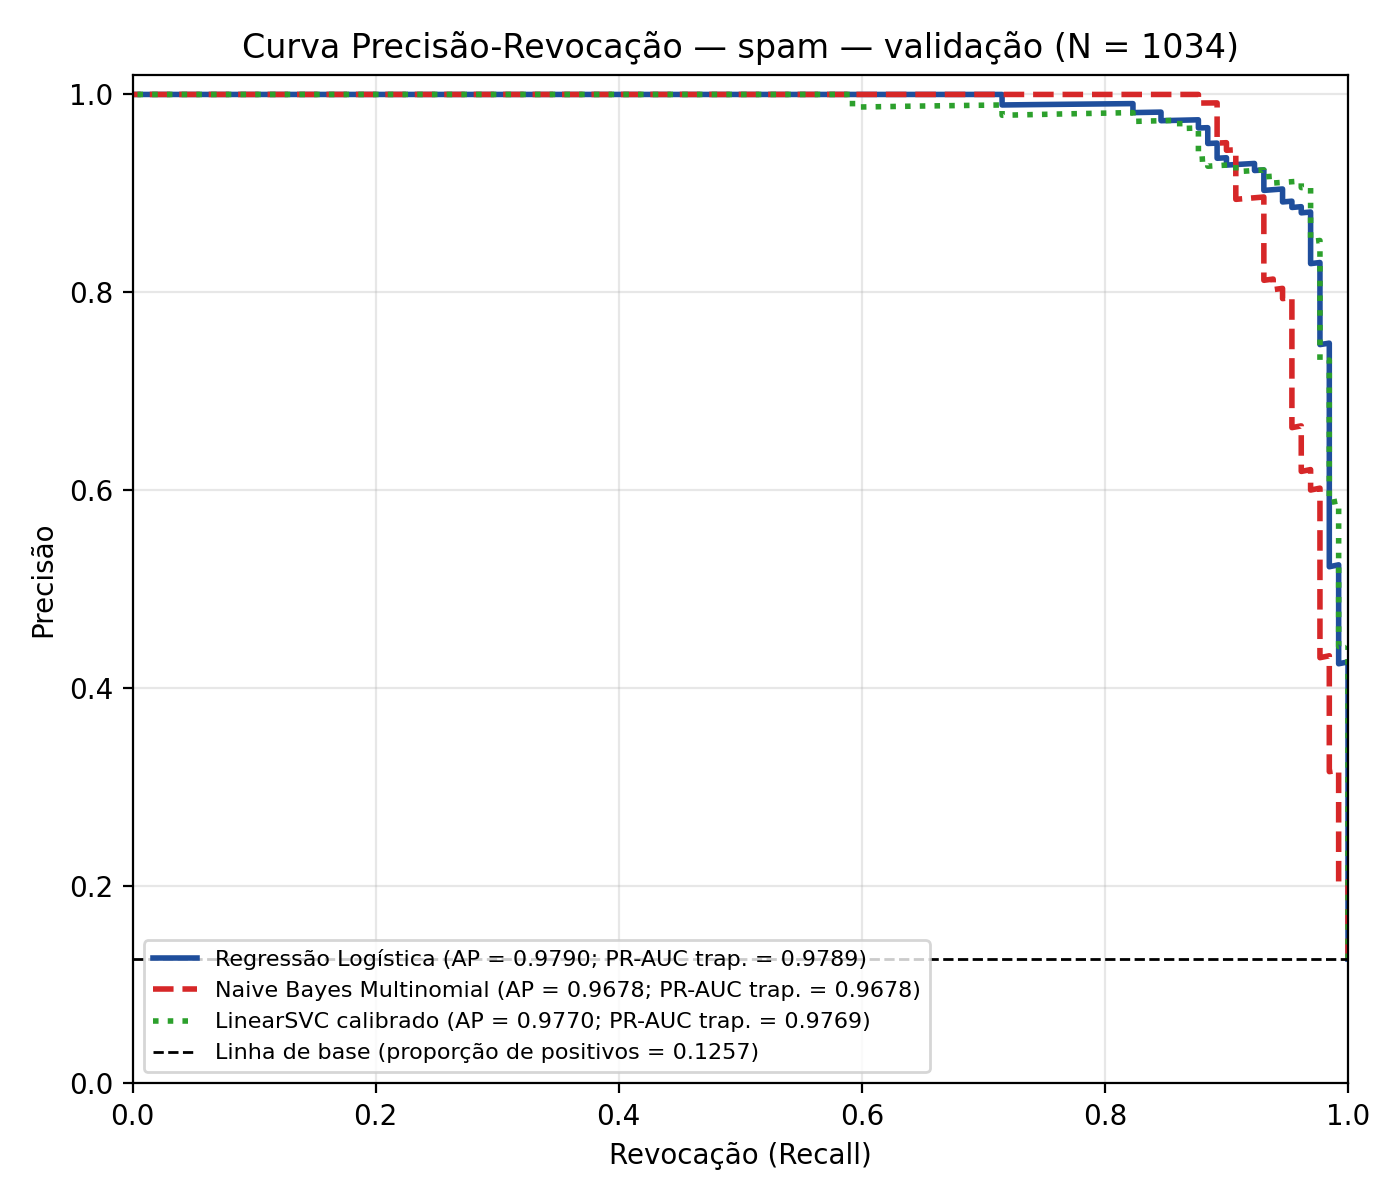

In [10]:
n_val = len(y_val)
show(evaluate.plot_roc(y_val, val_probas, OUT / "03_curva_roc_validacao.png",
                       f"Curva ROC — {DOMAIN} — validação (N = {n_val})"))
show(evaluate.plot_pr(y_val, val_probas, OUT / "04_curva_pr_validacao.png",
                      f"Curva Precisão-Revocação — {DOMAIN} — validação (N = {n_val})"))

## 8. Varredura de limiar do melhor modelo (validação)

In [11]:
varredura = evaluate.threshold_sweep(y_val, val_probas[best_name])
table(varredura, "varredura_limiar")

,limiar,TP,FP,TN,FN,TPR_recall,FPR,precisao
0,0.1,127,28,876,3,0.9769,0.0310,0.8194
1,0.2,123,13,891,7,0.9462,0.0144,0.9044
2,0.3,120,9,895,10,0.9231,0.0100,0.9302
3,0.4,116,7,897,14,0.8923,0.0077,0.9431
4,0.5,115,4,900,15,0.8846,0.0044,0.9664
5,0.6,109,2,902,21,0.8385,0.0022,0.9820
6,0.7,107,1,903,23,0.8231,0.0011,0.9907
7,0.8,97,1,903,33,0.7462,0.0011,0.9898
8,0.9,66,0,904,64,0.5077,0.0000,1.0000


## 9. Avaliação final no teste (melhor modelo, sem retreinar e sem ajustes)

[tempo] avaliação no teste: 0.0 s


,modelo,conjunto,limiar,acuracia,precisao,recall,f1,roc_auc,pr_auc_trapezoidal,average_precision_AP,TN,FP,FN,TP
0,Regressão Logística,teste,0.5,0.9807,0.9912,0.855,0.918,0.9903,0.9664,0.9665,903,1,19,112


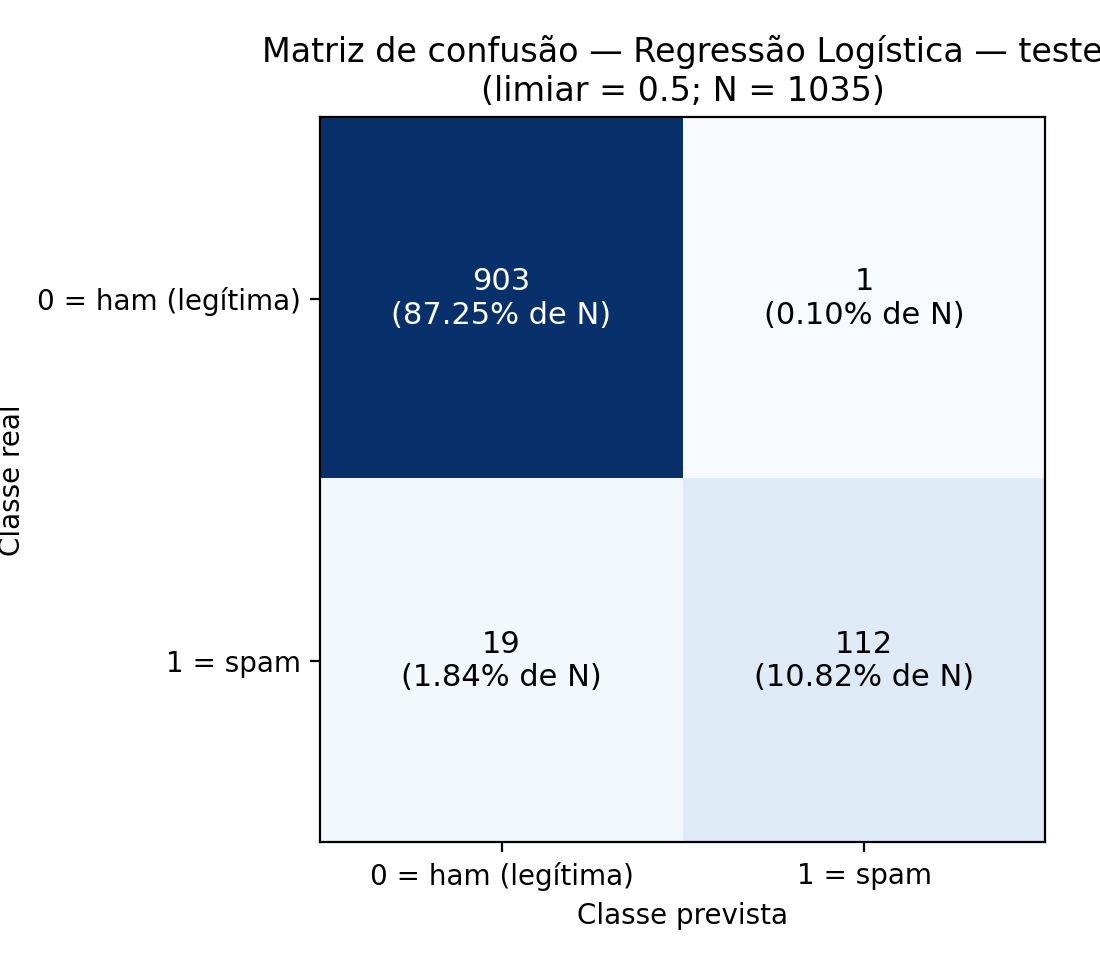

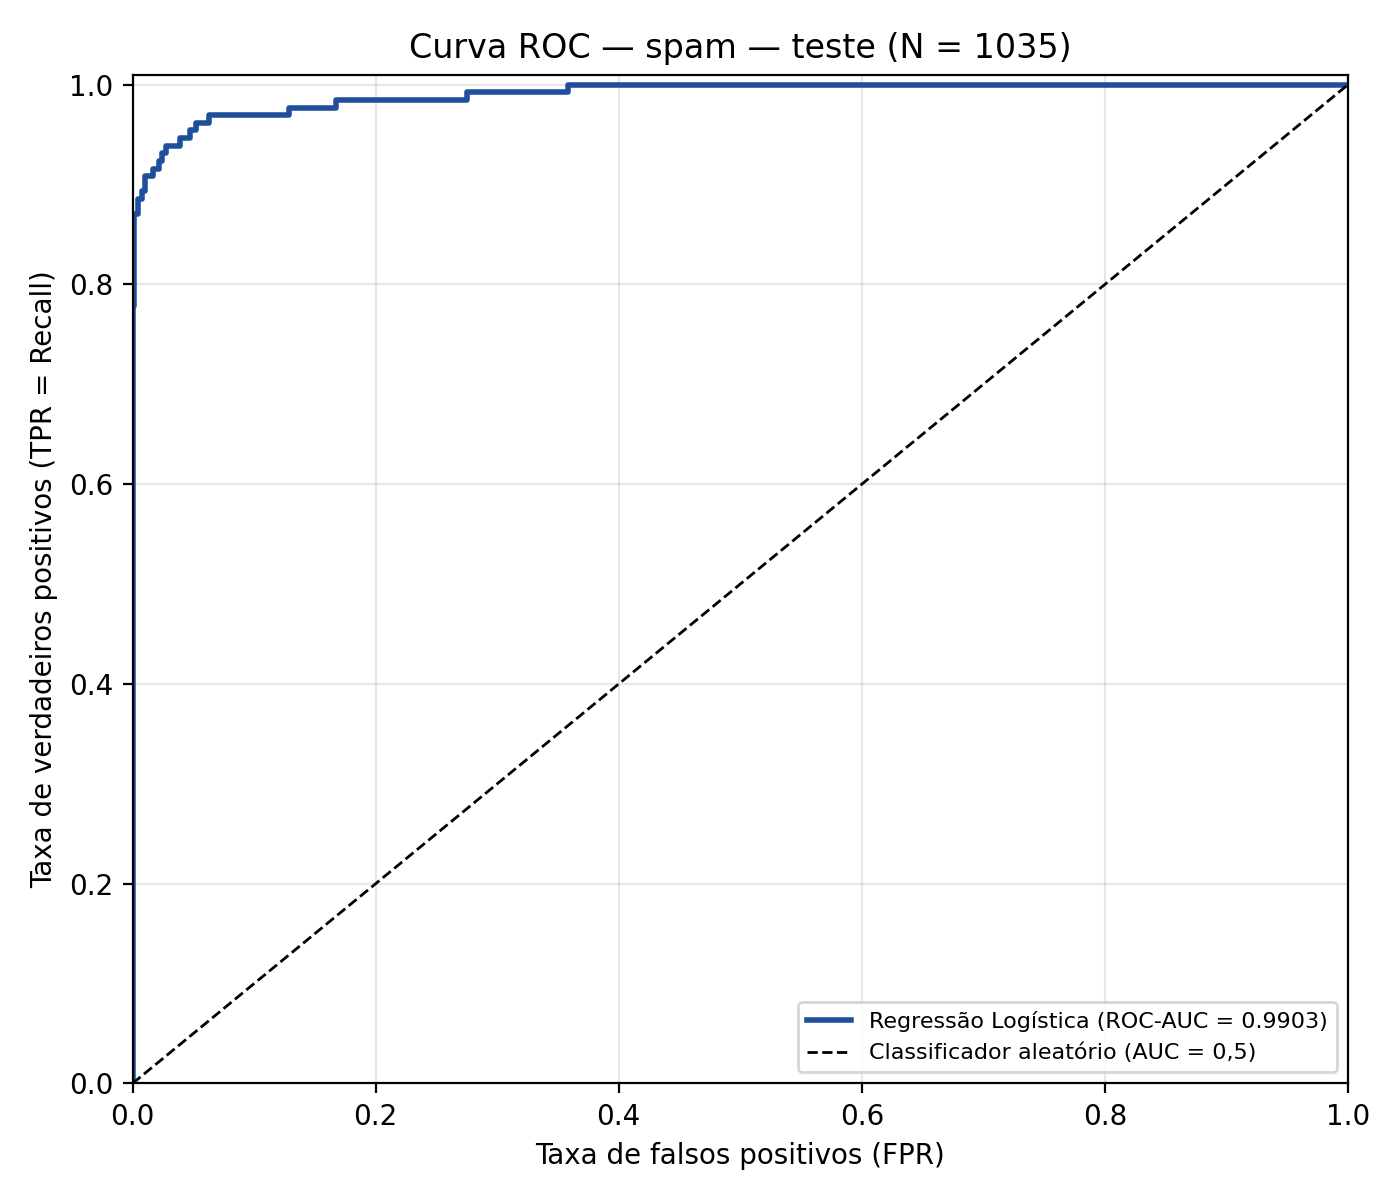

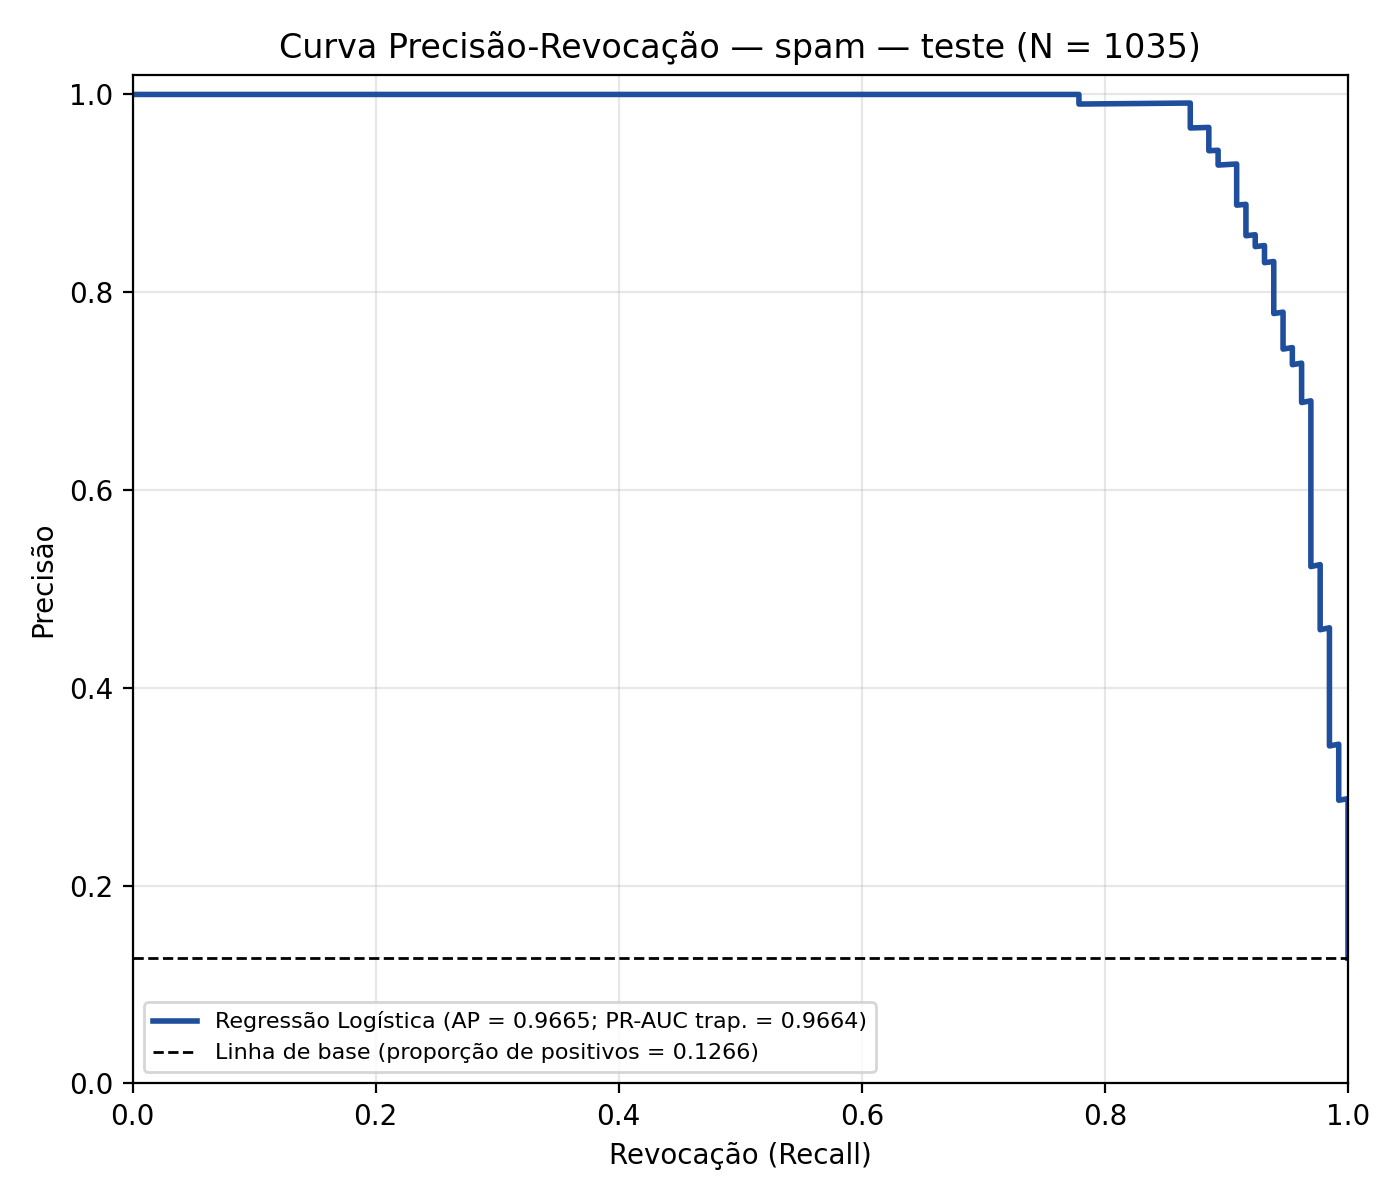

In [12]:
with timed("avaliação no teste"):
    p_test = pipeline.predict_positive(best, X_te)
    resultado_teste = evaluate.comparison_table(y_te, {best_name: p_test})
resultado_teste.insert(1, "conjunto", "teste")
table(resultado_teste, "resultado_teste")
n_te = len(y_te)
show(evaluate.plot_confusion(y_te, p_test, cfg, OUT / "05_matriz_confusao_teste.png",
                             f"Matriz de confusão — {best_name} — teste"))
show(evaluate.plot_roc(y_te, {best_name: p_test}, OUT / "06_curva_roc_teste.png",
                       f"Curva ROC — {DOMAIN} — teste (N = {n_te})"))
show(evaluate.plot_pr(y_te, {best_name: p_test}, OUT / "07_curva_pr_teste.png",
                      f"Curva Precisão-Revocação — {DOMAIN} — teste (N = {n_te})"))

## 10. SHAP beeswarm do melhor modelo (amostra do teste)

[tempo] SHAP: 1.2 s


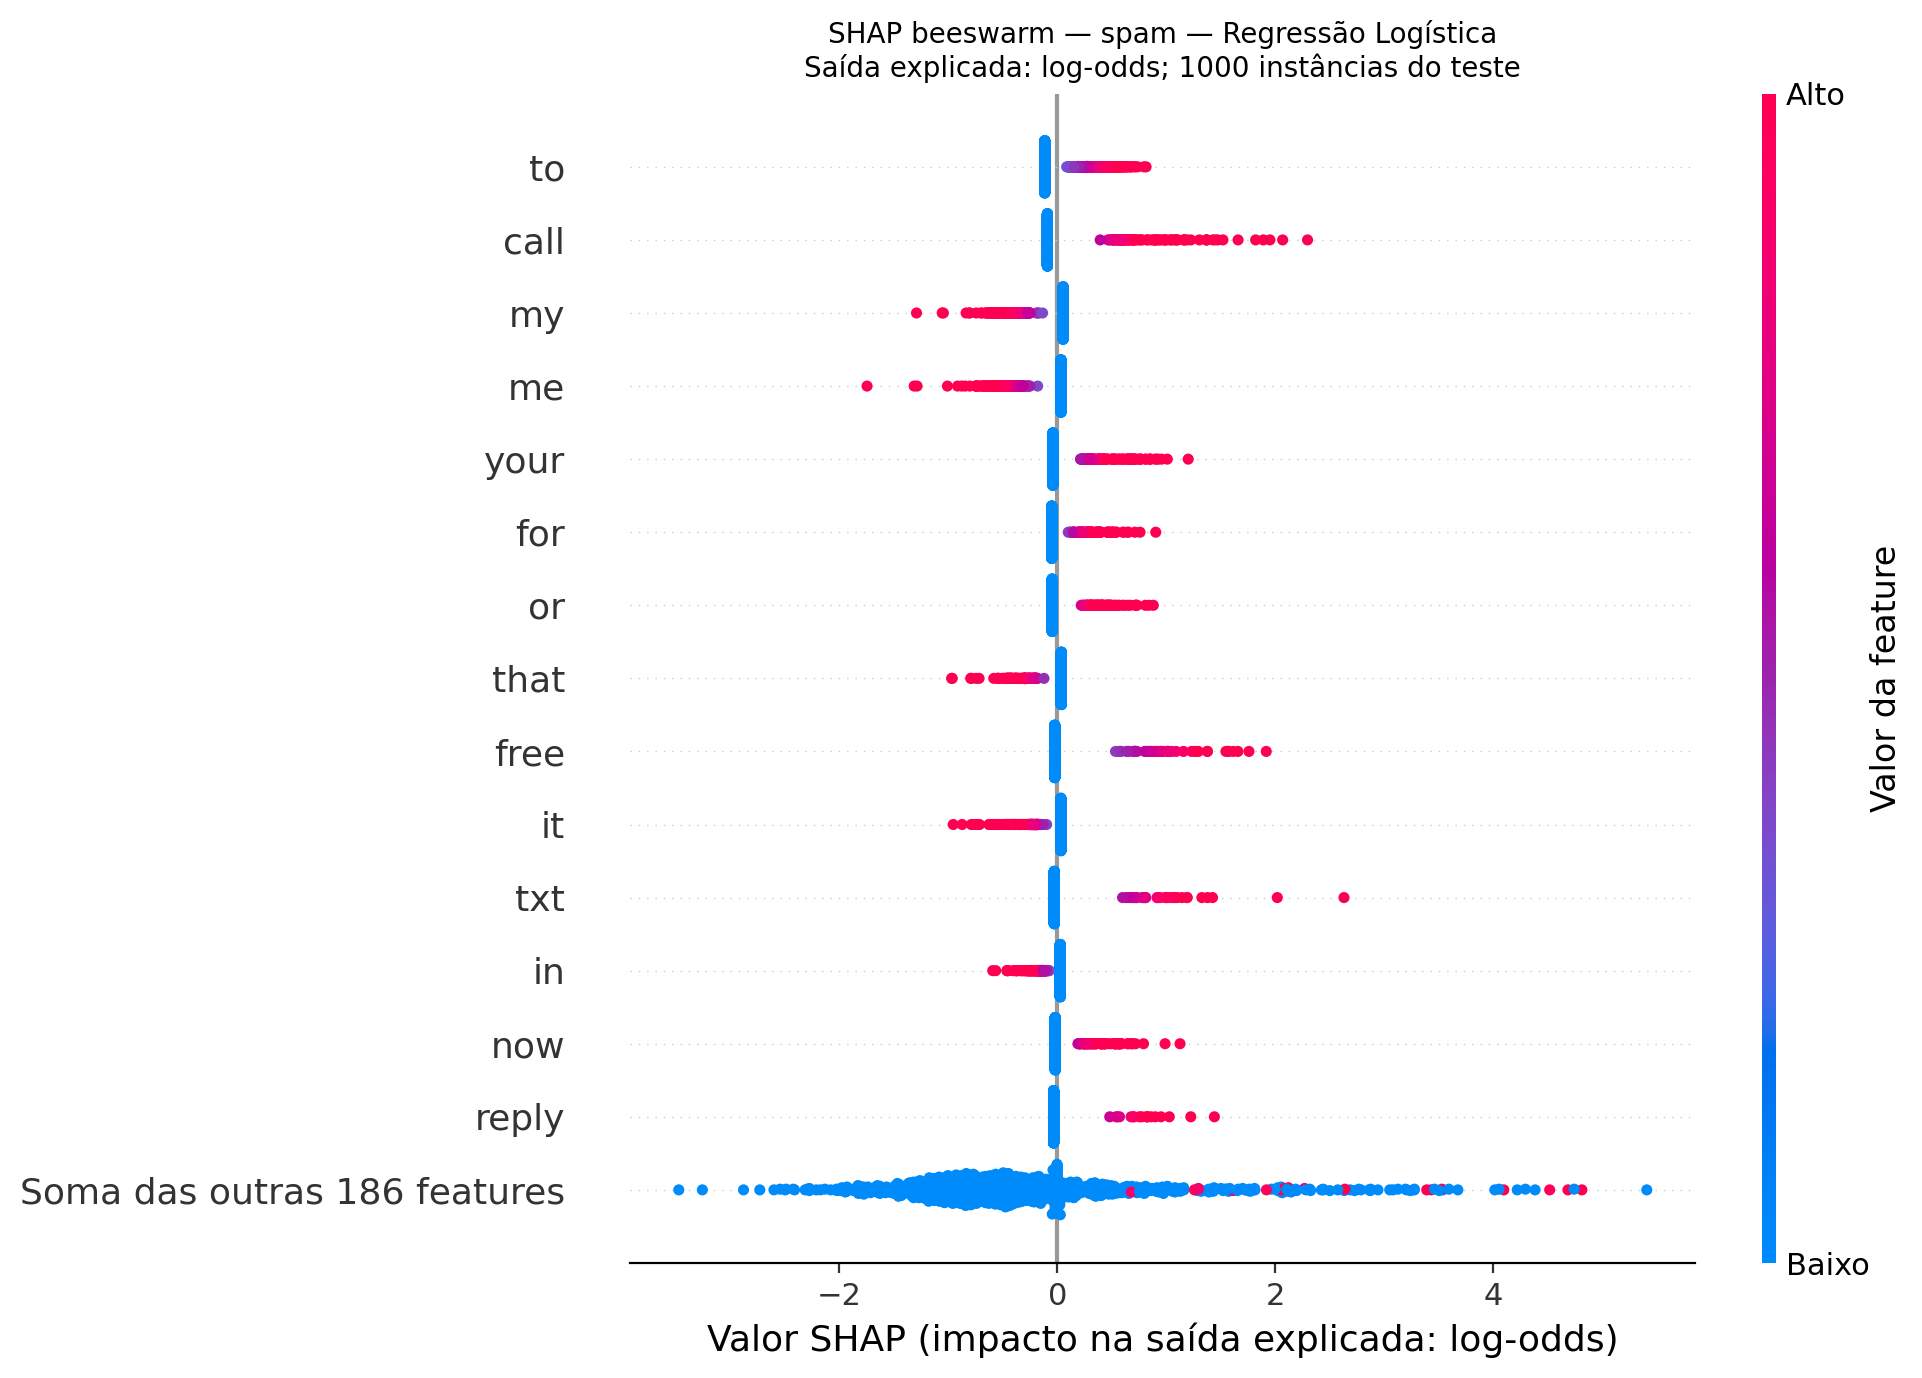

Domínio: spam
Modelo explicado: Regressão Logística (LogisticRegression)
Explainer: LinearExplainer (interventional)
Saída do modelo explicada: log-odds (escala linear) da classe positiva da Regressão Logística
Dados explicados: 1000 instâncias aleatórias do conjunto de TESTE (random_state=42), transformadas pelo pré-processamento do pipeline
Conjunto de fundo (background): 100 instâncias aleatórias do TREINO
Número de features após o pré-processamento: 34311
Beeswarm: max_display=15; cor = valor da feature (vermelho alto, azul baixo); eixo X = contribuição SHAP para a saída explicada
Somente as 200 features de maior média |SHAP| foram mantidas para o gráfico (vocabulário TF-IDF muito grande).


,posicao,feature,media_abs_shap,correlacao_valor_shap,leitura
0,1,to,0.1831,1.0,valores altos aumentam a saída
1,2,call,0.1637,1.0,valores altos aumentam a saída
2,3,my,0.0988,-1.0,valores altos diminuem a saída
3,4,me,0.0939,-1.0,valores altos diminuem a saída
4,5,your,0.0894,1.0,valores altos aumentam a saída
5,6,for,0.0763,1.0,valores altos aumentam a saída
6,7,or,0.0737,1.0,valores altos aumentam a saída
7,8,that,0.0688,-1.0,valores altos diminuem a saída
8,9,free,0.0657,1.0,valores altos aumentam a saída
9,10,it,0.0647,-1.0,valores altos diminuem a saída


In [13]:
with timed("SHAP"):
    shap_res = explain.explain_model(DOMAIN, best_name, best, X_tr, X_te, OUT,
                                     OUT / "08_shap_beeswarm.png")
show(OUT / "08_shap_beeswarm.png")
print("\n".join(shap_res["info"]))
display(evaluate.round_table(shap_res["top10"]))

## 11. Parte 1 aplicada ao melhor modelo

Cortes escolhidos **somente na validação** e aplicados ao teste **sem ajuste**.

t1 = 0.11 | t2 = 0.70  (max_fn_rate = 0.03 sobre positivos, max_fp_rate = 0.002 sobre negativos)


,t1,t2,volume_manual,cobertura_automatica,fn_auto,fn_auto_sobre_positivos,fp_auto,fp_auto_sobre_negativos,violacao,viavel
0,0.11,0.70,0.0435,0.9565,3,0.0231,1,0.0011,0.0,True
1,0.11,0.71,0.0445,0.9555,3,0.0231,1,0.0011,0.0,True
2,0.10,0.70,0.0455,0.9545,3,0.0231,1,0.0011,0.0,True
3,0.11,0.72,0.0464,0.9536,3,0.0231,1,0.0011,0.0,True
4,0.10,0.71,0.0464,0.9536,3,0.0231,1,0.0011,0.0,True
5,0.11,0.73,0.0474,0.9526,3,0.0231,1,0.0011,0.0,True
6,0.11,0.74,0.0474,0.9526,3,0.0231,1,0.0011,0.0,True
7,0.11,0.75,0.0484,0.9516,3,0.0231,1,0.0011,0.0,True
8,0.10,0.72,0.0484,0.9516,3,0.0231,1,0.0011,0.0,True
9,0.10,0.73,0.0493,0.9507,3,0.0231,1,0.0011,0.0,True


,faixa,regra,n,pct_populacao_sobre_N,n_positivos,pct_positivos_sobre_n_faixa,n_negativos,pct_negativos_sobre_n_faixa
0,Negativa automática,p < t1,881,85.20,3,0.34,878,99.66
1,Análise manual,t1 ≤ p < t2,45,4.35,20,44.44,25,55.56
2,Positiva automática,p ≥ t2,108,10.44,107,99.07,1,0.93
3,Total,"t1 = 0.11, t2 = 0.7",1034,100.00,130,12.57,904,87.43


,metrica,valor,valor_pct,numerador,denominador,descricao_denominador,descricao
0,fn_auto,3.0000,NaN,3,<NA>,— (contagem),positivos classificados automaticamente como n...
1,fn_auto_sobre_positivos,0.0231,2.31,3,130,total de positivos,proporção dos positivos que caíram na faixa ne...
2,fn_auto_sobre_N,0.0029,0.29,3,1034,N (total de instâncias),proporção de N que é positivo e caiu na faixa ...
3,fp_auto,1.0000,NaN,1,<NA>,— (contagem),negativos classificados automaticamente como p...
4,fp_auto_sobre_negativos,0.0011,0.11,1,904,total de negativos,proporção dos negativos que caíram na faixa po...
5,fp_auto_sobre_N,0.0010,0.10,1,1034,N (total de instâncias),proporção de N que é negativo e caiu na faixa ...
6,cobertura_automatica,0.9565,95.65,989,1034,N (total de instâncias),proporção de N decidida automaticamente (fora ...
7,volume_manual,0.0435,4.35,45,1034,N (total de instâncias),proporção de N encaminhada à análise manual


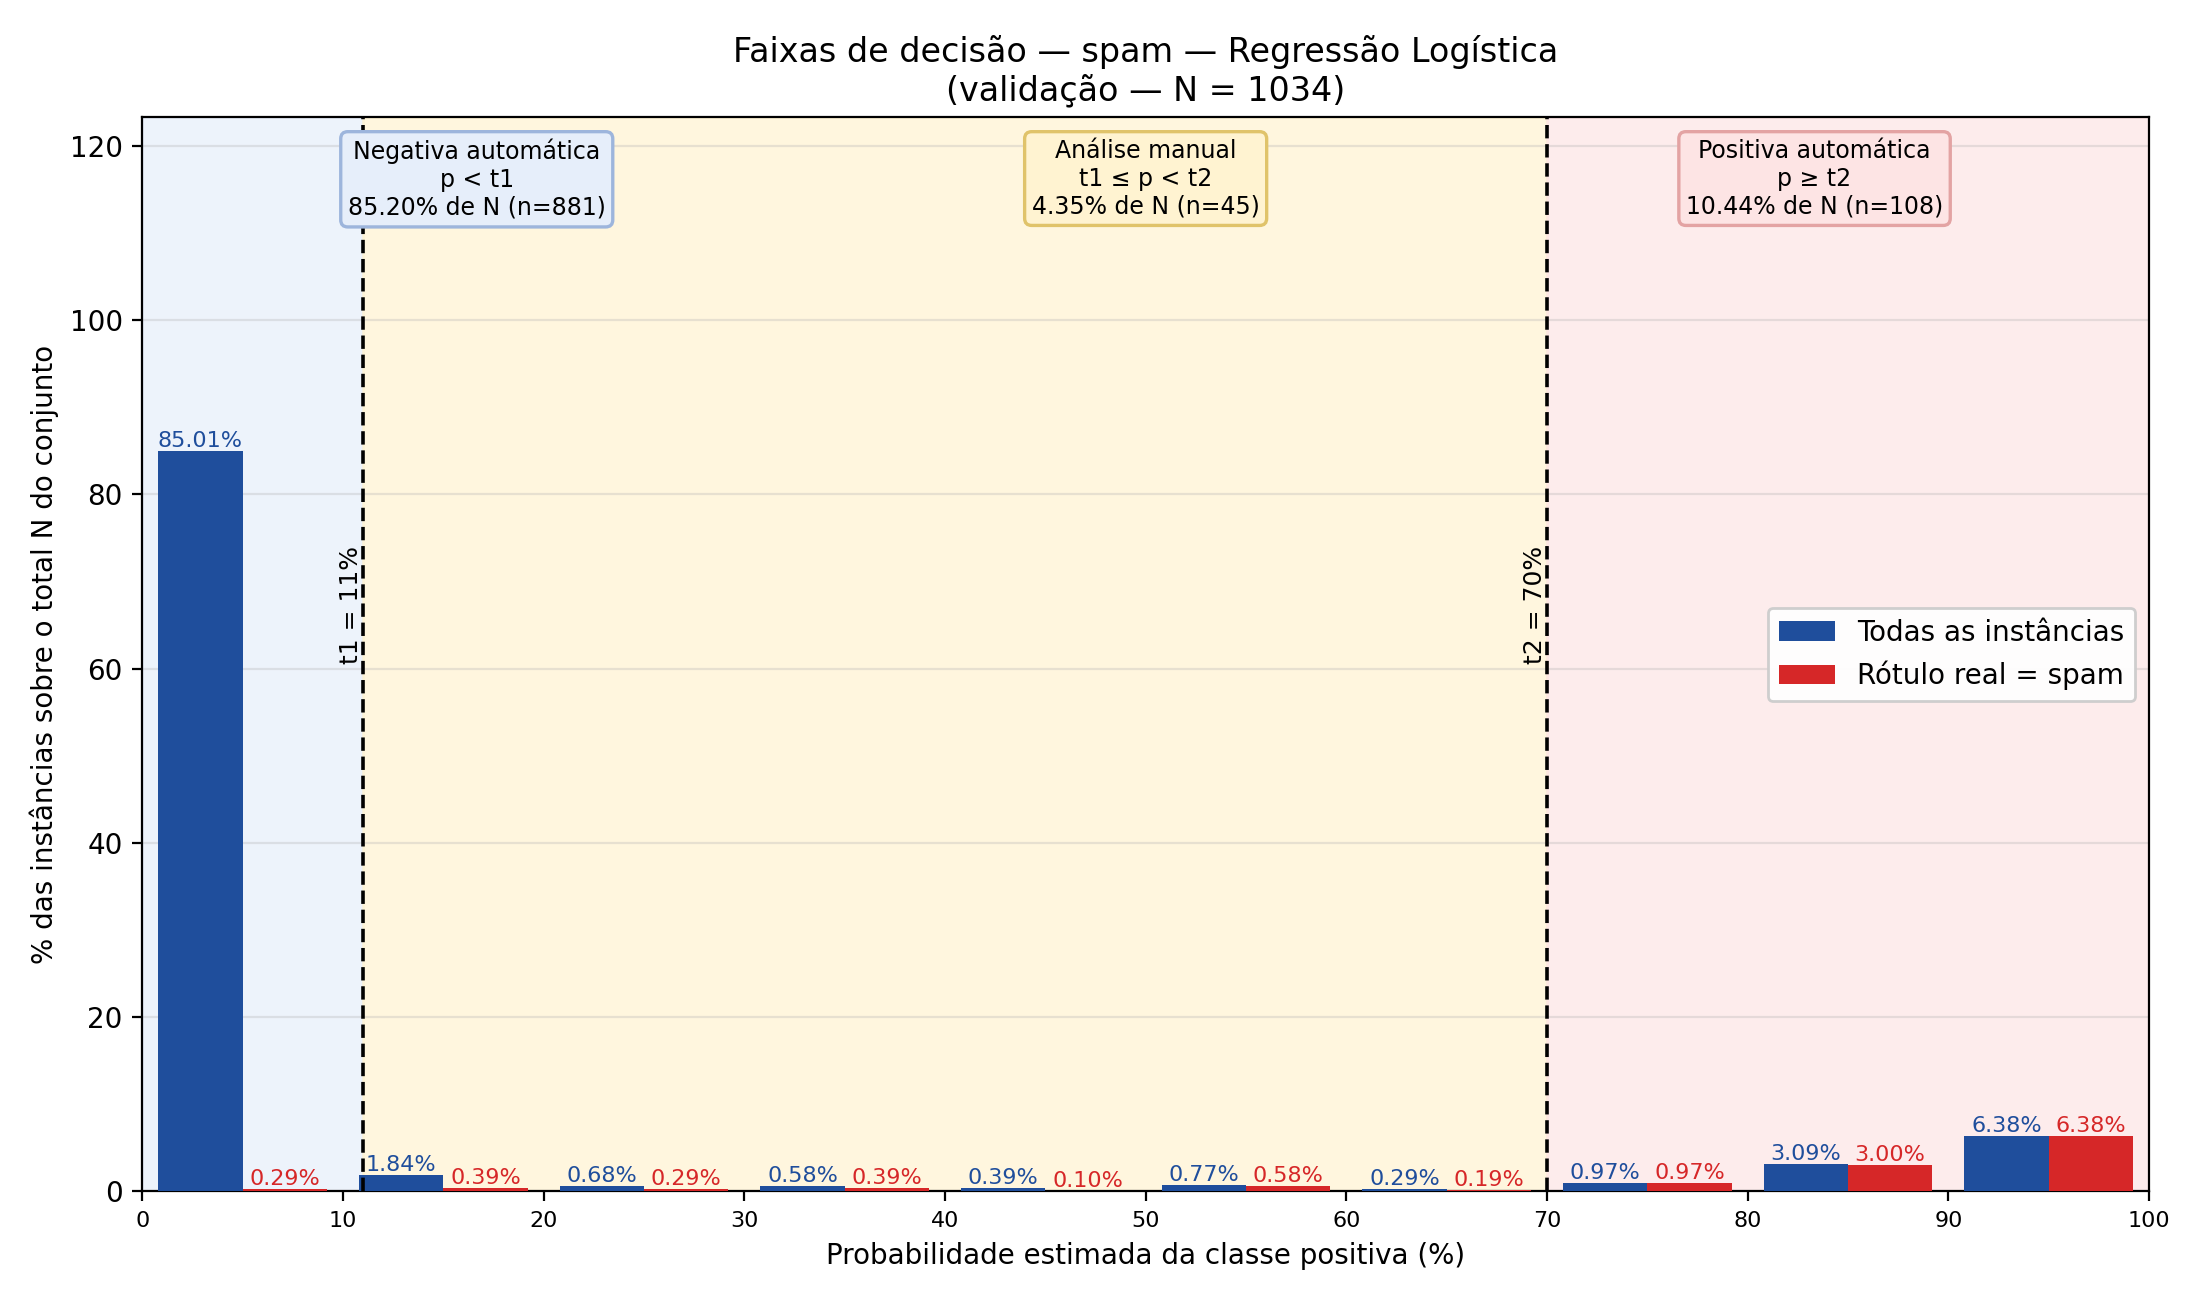

In [14]:
p_val = val_probas[best_name]
(t1, t2), rep_val, tradeoff = cutoff_hist.choose_cutoffs(
    y_val, p_val, cfg["max_fn_rate"], cfg["max_fp_rate"])
print(f"t1 = {t1:.2f} | t2 = {t2:.2f}  (max_fn_rate = {cfg['max_fn_rate']} sobre positivos, "
      f"max_fp_rate = {cfg['max_fp_rate']} sobre negativos)")
table(tradeoff, "faixas/tradeoff_validacao")
table(rep_val["faixas"], "faixas/band_report_validacao_faixas")
table(rep_val["erros"], "faixas/band_report_validacao_erros")
fig, _ = cutoff_hist.plot_cutoff_histogram(
    y_val, p_val, cfg["bin_width"], t1, t2, cfg["positive_label"],
    f"Faixas de decisão — {DOMAIN} — {best_name}", FX / "09_histograma_faixas_validacao.png",
    dataset_name="validação")
plt.close(fig)
show(FX / "09_histograma_faixas_validacao.png")

,faixa,regra,n,pct_populacao_sobre_N,n_positivos,pct_positivos_sobre_n_faixa,n_negativos,pct_negativos_sobre_n_faixa
0,Negativa automática,p < t1,881,85.12,8,0.91,873,99.09
1,Análise manual,t1 ≤ p < t2,52,5.02,21,40.38,31,59.62
2,Positiva automática,p ≥ t2,102,9.86,102,100.00,0,0.00
3,Total,"t1 = 0.11, t2 = 0.7",1035,100.00,131,12.66,904,87.34


,metrica,valor,valor_pct,numerador,denominador,descricao_denominador,descricao
0,fn_auto,8.0000,NaN,8,<NA>,— (contagem),positivos classificados automaticamente como n...
1,fn_auto_sobre_positivos,0.0611,6.11,8,131,total de positivos,proporção dos positivos que caíram na faixa ne...
2,fn_auto_sobre_N,0.0077,0.77,8,1035,N (total de instâncias),proporção de N que é positivo e caiu na faixa ...
3,fp_auto,0.0000,NaN,0,<NA>,— (contagem),negativos classificados automaticamente como p...
4,fp_auto_sobre_negativos,0.0000,0.00,0,904,total de negativos,proporção dos negativos que caíram na faixa po...
5,fp_auto_sobre_N,0.0000,0.00,0,1035,N (total de instâncias),proporção de N que é negativo e caiu na faixa ...
6,cobertura_automatica,0.9498,94.98,983,1035,N (total de instâncias),proporção de N decidida automaticamente (fora ...
7,volume_manual,0.0502,5.02,52,1035,N (total de instâncias),proporção de N encaminhada à análise manual


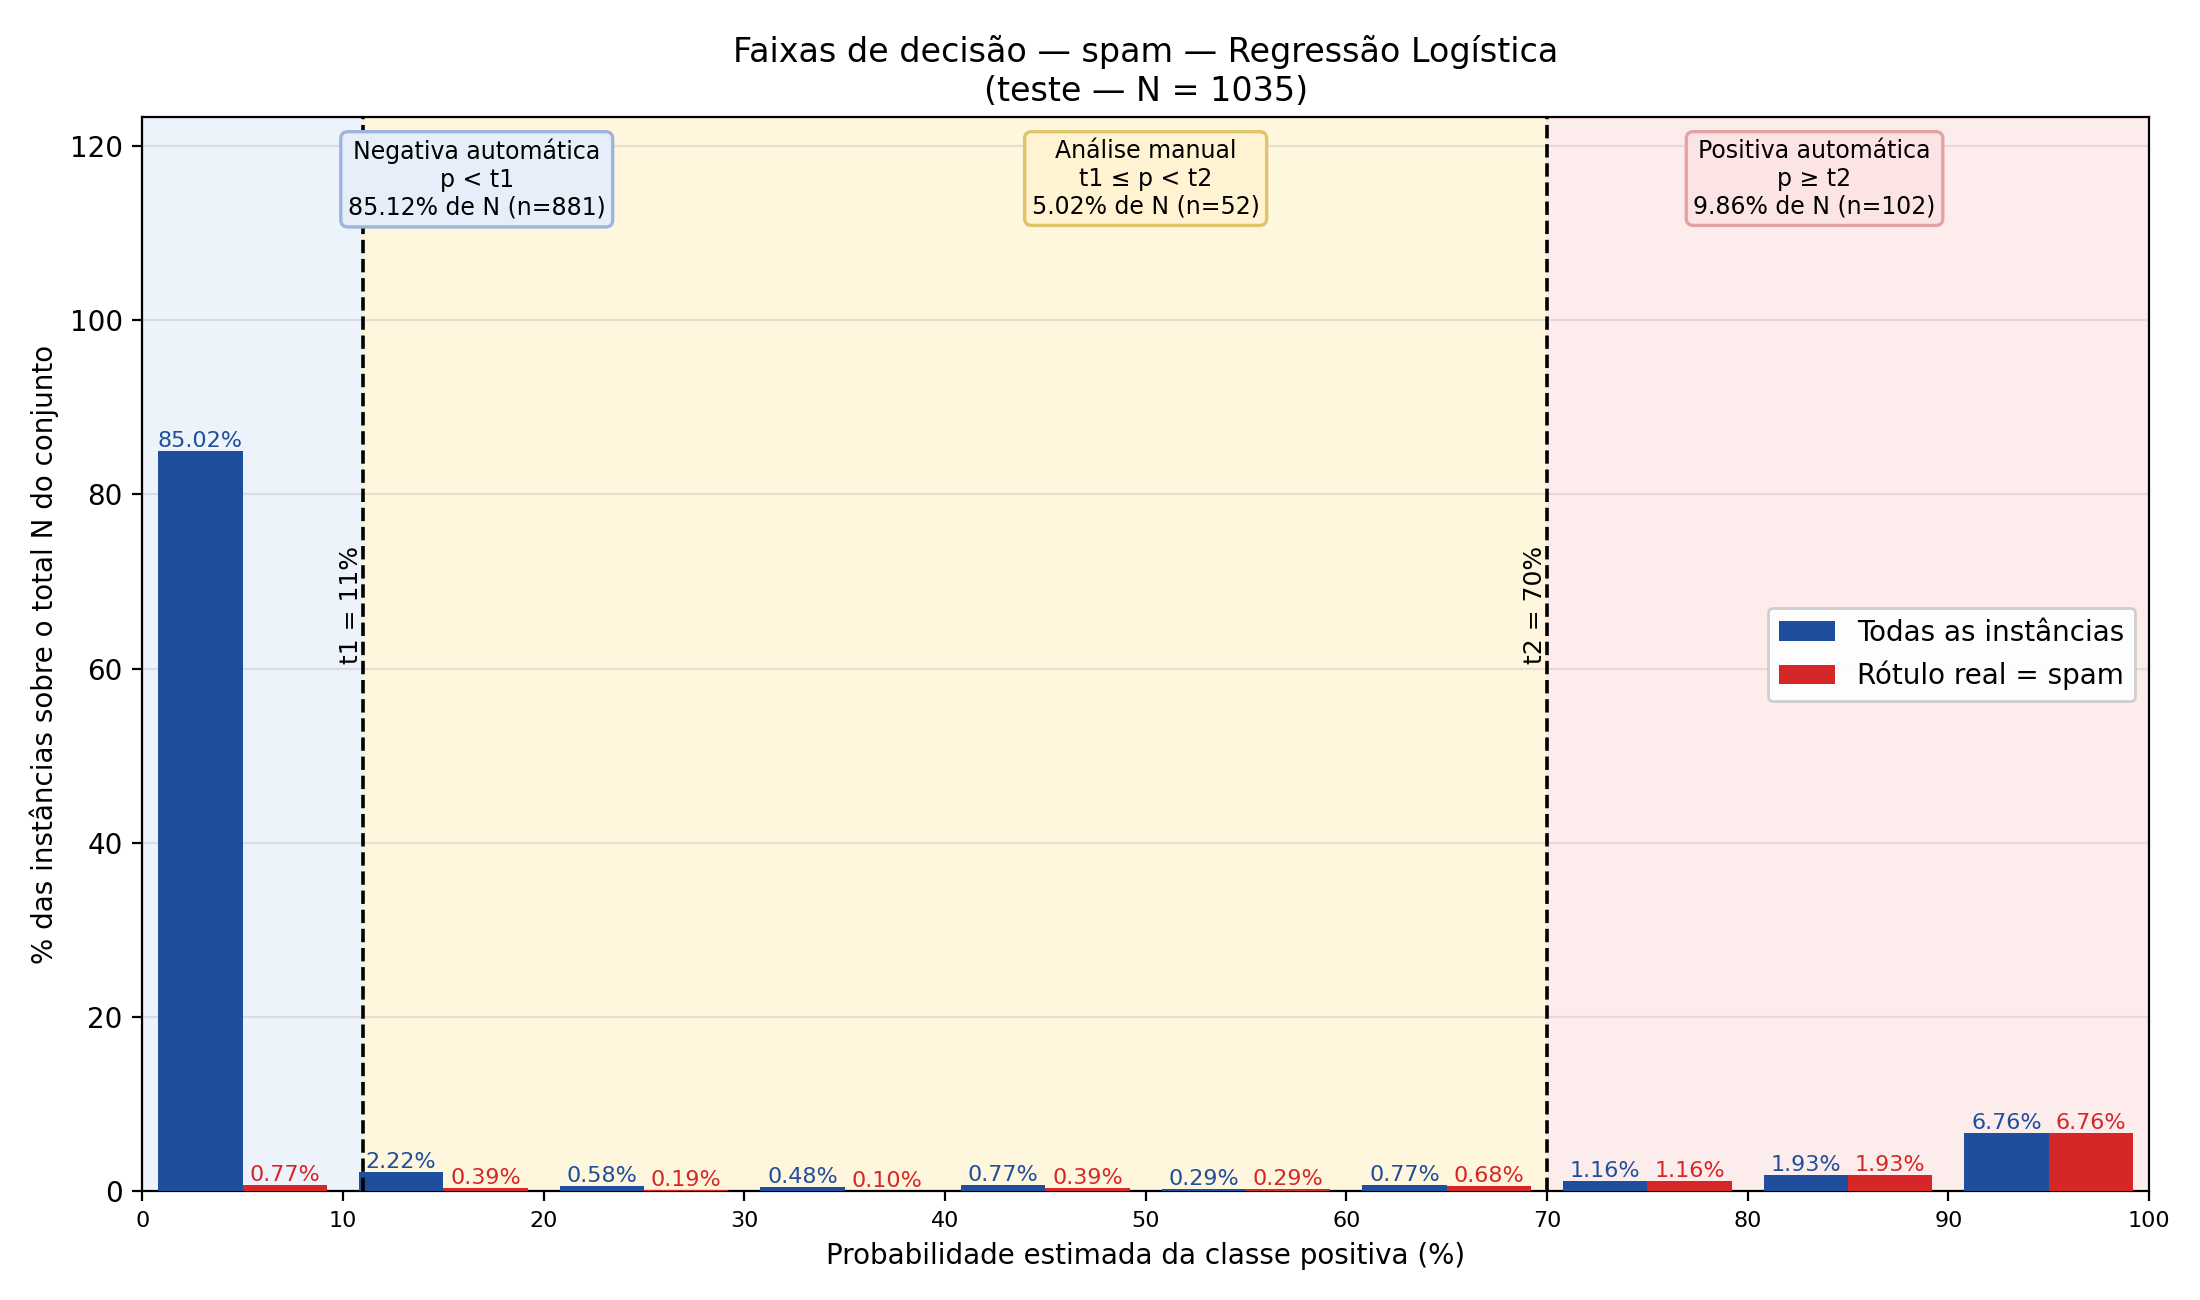

In [15]:
rep_test = cutoff_hist.band_report(y_te, p_test, t1, t2)   # mesmos t1 e t2 da validação
table(rep_test["faixas"], "faixas/band_report_teste_faixas")
table(rep_test["erros"], "faixas/band_report_teste_erros")
fig, _ = cutoff_hist.plot_cutoff_histogram(
    y_te, p_test, cfg["bin_width"], t1, t2, cfg["positive_label"],
    f"Faixas de decisão — {DOMAIN} — {best_name}", FX / "10_histograma_faixas_teste.png",
    dataset_name="teste")
plt.close(fig)
show(FX / "10_histograma_faixas_teste.png")
pd.DataFrame({"y_true": y_val, "y_proba": p_val}).to_csv(OUT / "preds_validacao.csv", index=False)
pd.DataFrame({"y_true": y_te, "y_proba": p_test}).to_csv(OUT / "preds_teste.csv", index=False)

## 12. Resumo numérico

In [16]:
tempos = pd.DataFrame({"etapa": list(pipeline.TIMINGS), "segundos": list(pipeline.TIMINGS.values())})
blocos = [
    ("Balanceamento", balanceamento),
    ("Split 60/20/20", pipeline.split_table(splits)),
    (f"Hiperparâmetros vencedores (CV {config.CV_SPLITS} folds, {cfg['target_metric']})",
     hiperparametros),
    (f"Comparação na validação (limiar = {T})", comparacao),
    ("Melhor modelo", selecao),
    (f"Resultado no teste (limiar = {T})", resultado_teste),
    ("SHAP — informações", shap_res["info"]),
    ("SHAP — top 10 features (média |SHAP|)", shap_res["top10"]),
    ("Cortes (escolhidos na validação)",
     [f"t1 = {t1:.2f}", f"t2 = {t2:.2f}",
      f"max_fn_rate = {cfg['max_fn_rate']} (sobre positivos)",
      f"max_fp_rate = {cfg['max_fp_rate']} (sobre negativos)"]),
    ("Trade-off (10 melhores pares viáveis, validação)", tradeoff),
    ("band_report — validação — faixas", rep_val["faixas"]),
    ("band_report — validação — erros", rep_val["erros"].drop(columns="descricao")),
    ("band_report — teste — faixas", rep_test["faixas"]),
    ("band_report — teste — erros", rep_test["erros"].drop(columns="descricao")),
    ("Tempo de execução (s)", tempos),
    ("Figuras geradas", FIGS),
]
resumo = evaluate.write_summary(OUT / "resumo_resultados.md",
                                f"Resumo de resultados — {DOMAIN}", blocos)
print("Resumo salvo em", resumo)

Resumo salvo em C:\Users\otavi\OneDrive\Desktop\data science\a2\outputs\spam\resumo_resultados.md
